# Day 7: Session 7B - Name the Columns, Not the Colours

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7b_seaborn.html)

Date: 09/09/2026

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://eds-217-essential-python.github.io/data/messy_field_survey.csv'
survey = pd.read_csv(url)

survey = survey.drop_duplicates()

survey['site'] = survey['site'].str.strip()
survey['site'] = survey['site'].str.lower()
survey['site'] = survey['site'].str.replace('-', '_')

survey['pH'] = survey['pH'].str.replace(',', '.')
survey['pH'] = survey['pH'].astype(float)

survey = survey.dropna(subset=['temperature_c', 'dissolved_oxygen_mg_L', 'conductivity_uS_cm'])
survey['n_replicates'] = survey['n_replicates'].fillna(1)
survey['n_replicates'] = survey['n_replicates'].astype(int)

survey = survey[survey['temperature_c'] > -100].copy()
survey = survey.rename(columns={'collection date': 'collection_date'})

survey.shape

(255, 7)

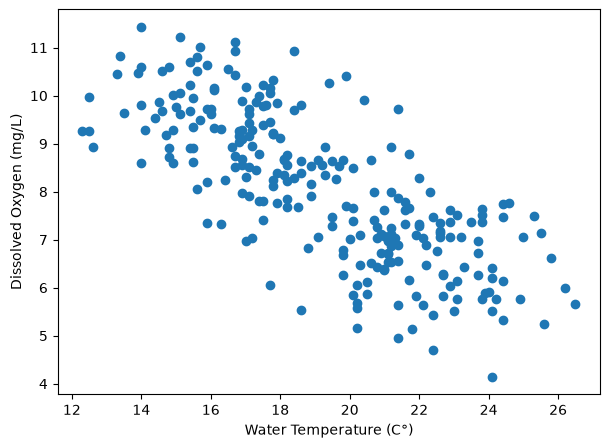

In [4]:
plt.figure(figsize = (7, 5))

plt.scatter(survey['temperature_c'], survey['dissolved_oxygen_mg_L'])

plt.xlabel('Water Temperature (C°)')
plt.ylabel('Dissolved Oxygen (mg/L)')
plt.show()




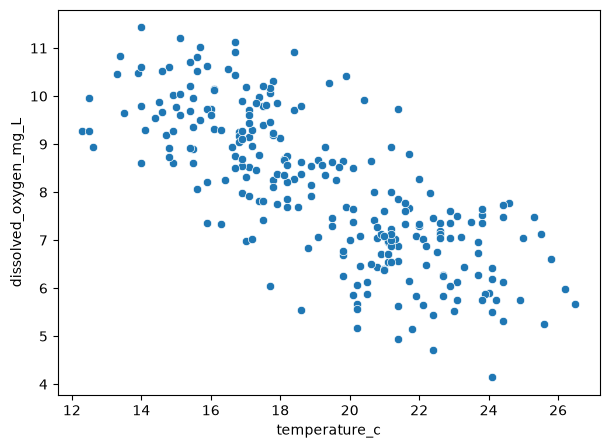

In [7]:
plt.figure(figsize = (7, 5))

sns.scatterplot(data = survey, x = 'temperature_c', y = 'dissolved_oxygen_mg_L')

plt.show()

sns.scatterplot(data = df, x = 'column name', y = 'column_name')

Text(0, 0.5, 'Dissolved oxygen (mg/L)')

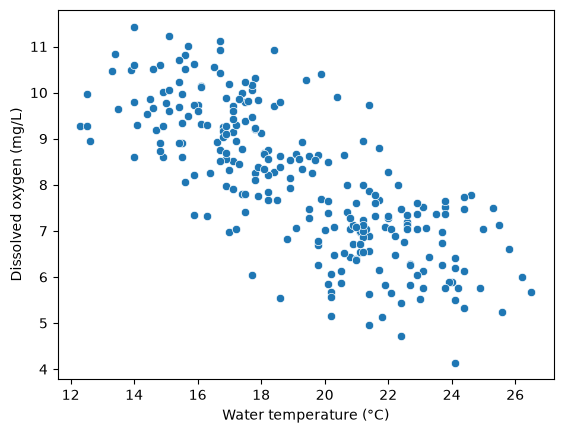

In [9]:
sns.scatterplot(data=survey, x='temperature_c', y='dissolved_oxygen_mg_L')
plt.xlabel('Water temperature (°C)') # you can hardcode and change the titles
plt.ylabel('Dissolved oxygen (mg/L)') # this is also changing the axis titles

In [11]:
print(survey.groupby('site')['dissolved_oxygen_mg_L'].mean().sort_values())
print(survey.groupby('site')['temperature_c'].mean().sort_values())

site
site_f     6.180233
site_c     6.873111
site_e     7.410930
site_b     8.601220
site_a     9.485909
site_d    10.053333
Name: dissolved_oxygen_mg_L, dtype: float64
site
site_d    15.179487
site_a    16.600000
site_b    18.102439
site_e    19.730233
site_c    21.911111
site_f    23.297674
Name: temperature_c, dtype: float64


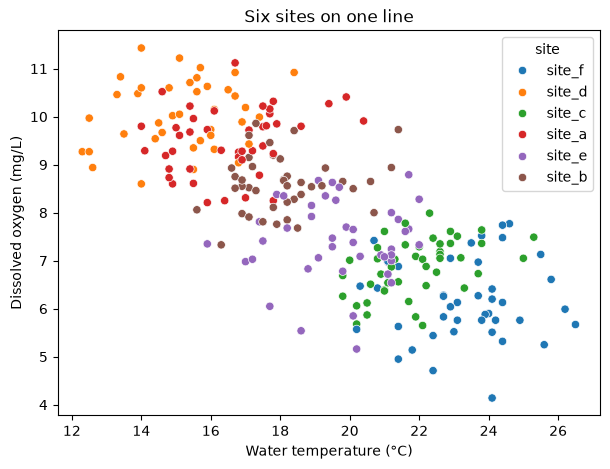

In [12]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=survey, x='temperature_c', y='dissolved_oxygen_mg_L', hue='site')

plt.xlabel('Water temperature (°C)')
plt.ylabel('Dissolved oxygen (mg/L)')
plt.title('Six sites on one line')
plt.show()

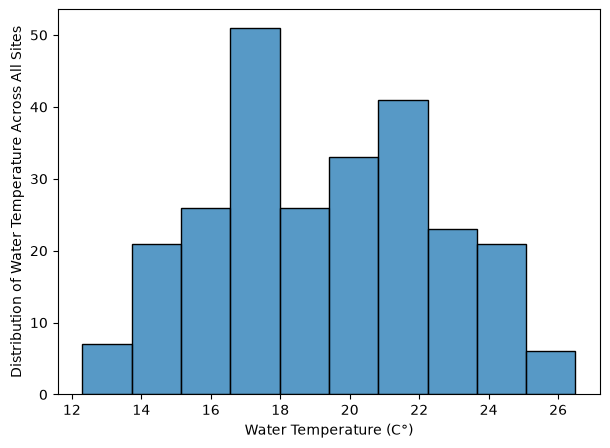

In [13]:
plt.figure(figsize = (7, 5))

sns.histplot(data = survey, x = 'temperature_c')

plt.xlabel('Water Temperature (C°)')
plt.ylabel('Distribution of Water Temperature Across All Sites')
plt.show()

Text(0, 0.5, '')

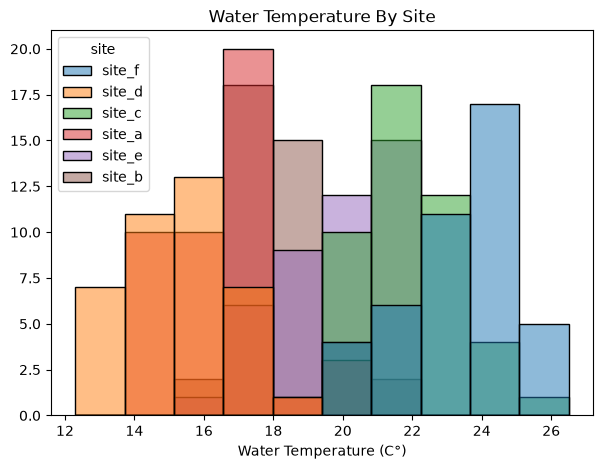

In [15]:
plt.figure(figsize = (7, 5))

sns.histplot(data = survey, x = 'temperature_c', hue = 'site')
plt.title('Water Temperature By Site')
plt.xlabel('Water Temperature (C°)')
plt.ylabel('')

<Axes: xlabel='pH', ylabel='Count'>

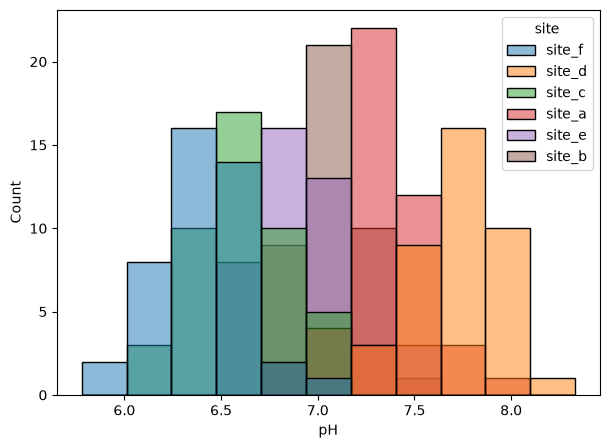

In [17]:
plt.figure(figsize = (7, 5))

sns.histplot(data = survey, x = 'pH', hue = 'site')

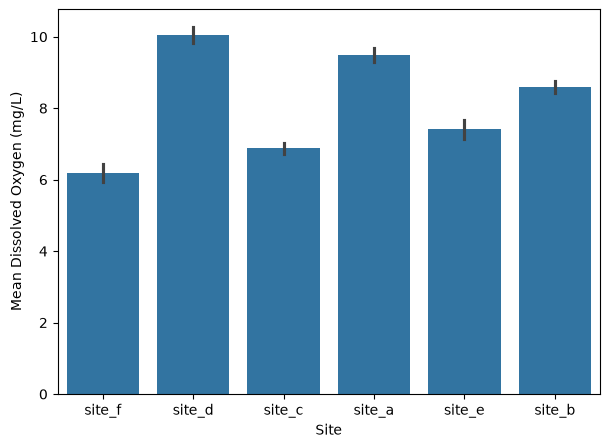

In [20]:
plt.figure(figsize = (7, 5))
sns.barplot(data = survey, x = 'site', y = 'dissolved_oxygen_mg_L')

plt.xlabel('Site')
plt.ylabel('Mean Dissolved Oxygen (mg/L)')
plt.show()



In [22]:
mean_do = survey.groupby('site')['dissolved_oxygen_mg_L'].mean().sort_values(ascending = False)

mean_do.round(2)

site
site_d    10.05
site_a     9.49
site_b     8.60
site_e     7.41
site_c     6.87
site_f     6.18
Name: dissolved_oxygen_mg_L, dtype: float64

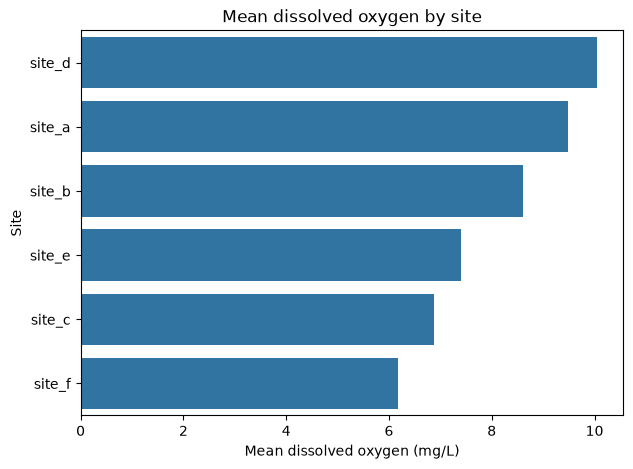

In [27]:
plt.figure(figsize = (7, 5))

sns.barplot(x = mean_do.values, y = mean_do.index)

plt.xlabel('Mean dissolved oxygen (mg/L)')
plt.ylabel('Site')
plt.title('Mean dissolved oxygen by site')
plt.show()

sns.barplot(x=series.values, y=series.index)   # horizontal bars, sorted as you sorted them

sns.barplot(y=series.values, x=series.index)   # vertical bars, same data

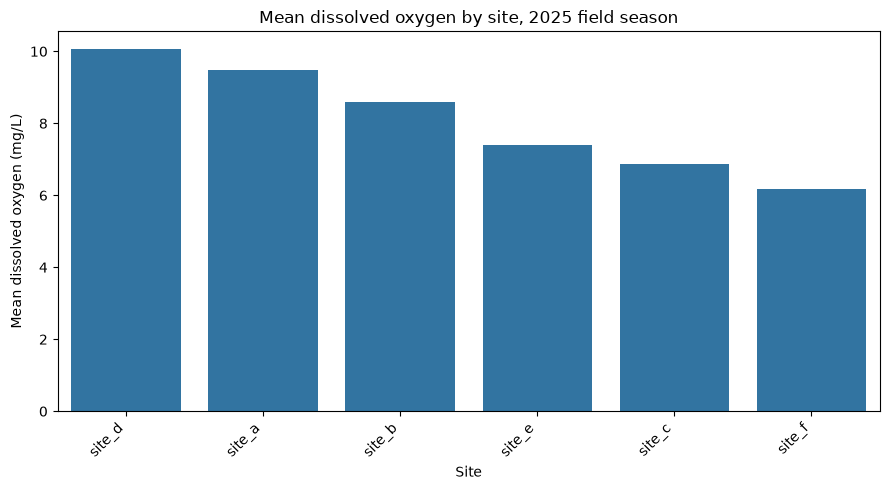

In [28]:
plt.figure(figsize=(9, 5))

sns.barplot(x=mean_do.index, y=mean_do.values)

plt.xlabel('Site')
plt.ylabel('Mean dissolved oxygen (mg/L)')
plt.title('Mean dissolved oxygen by site, 2025 field season')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()